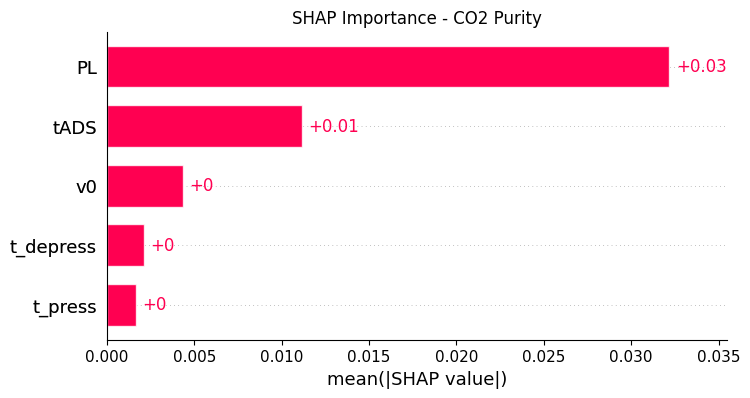

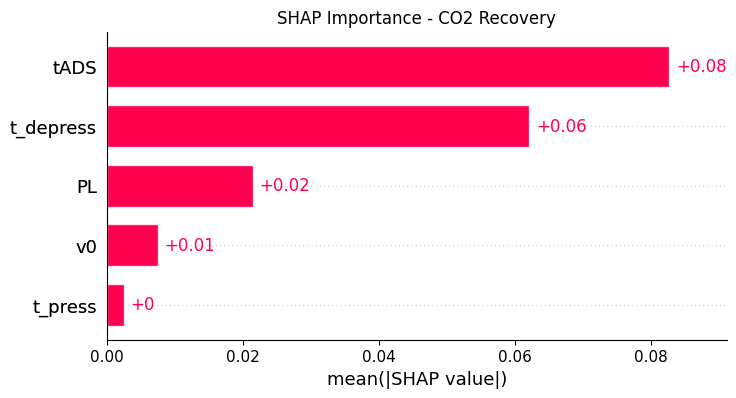

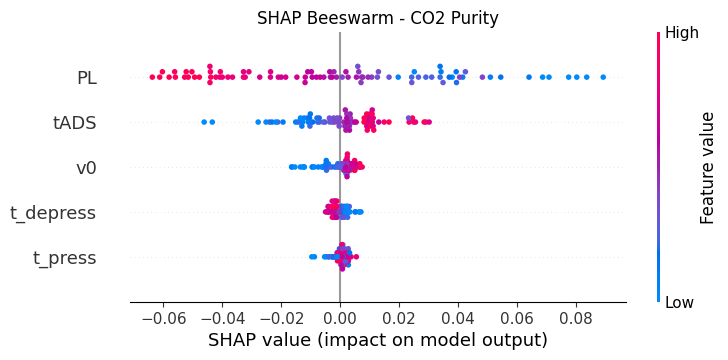

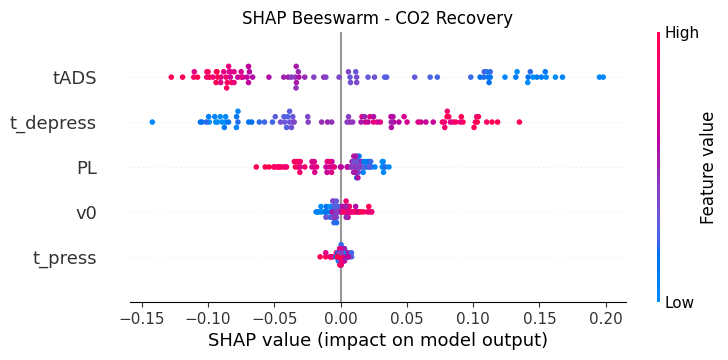

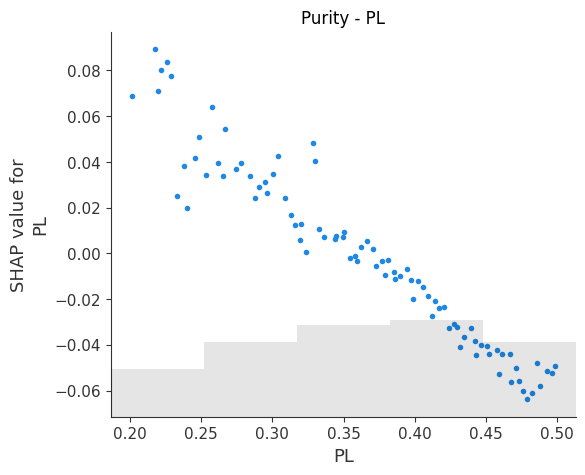

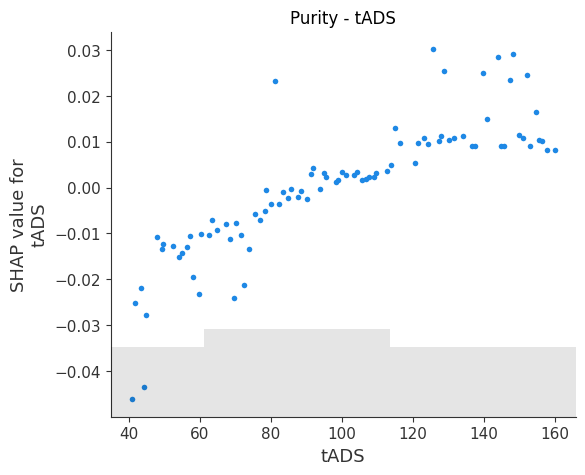

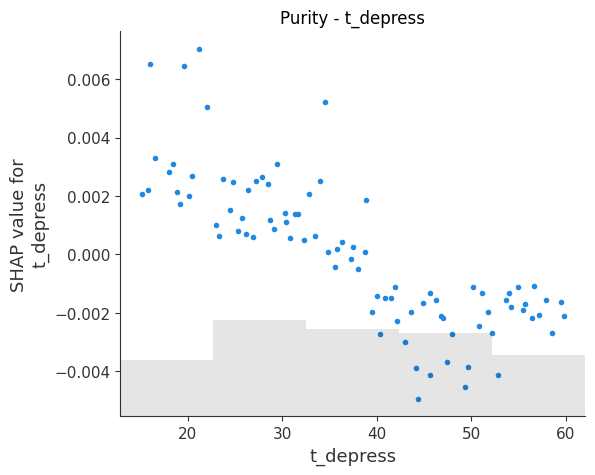

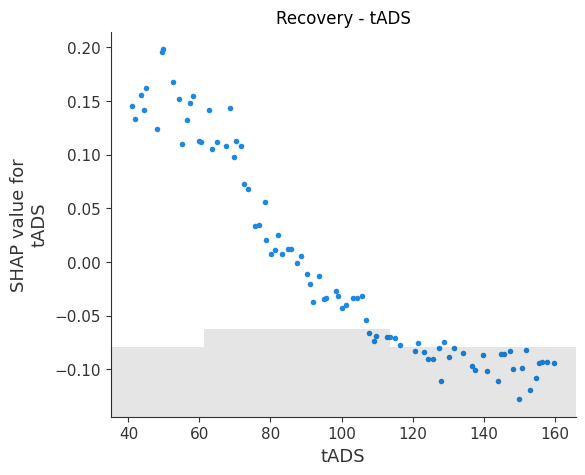

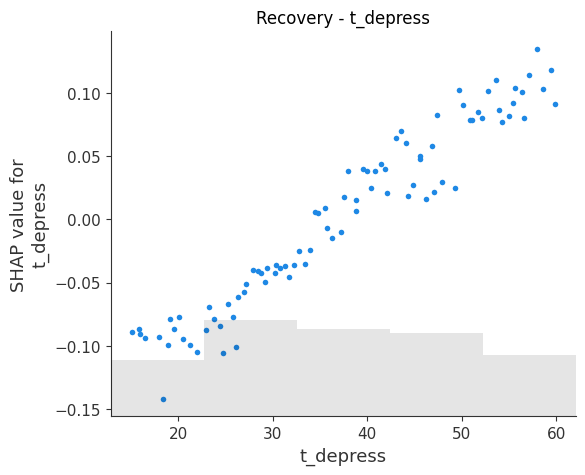

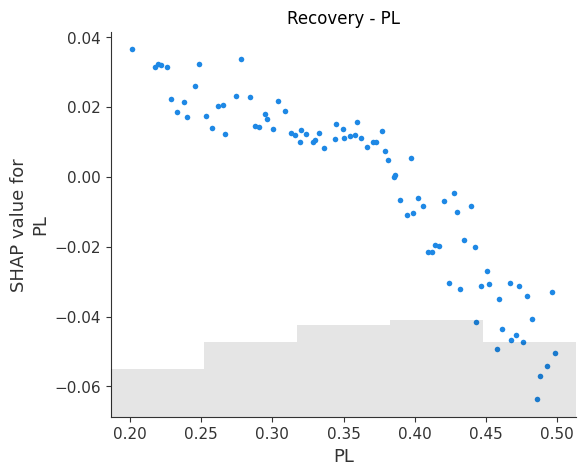

In [8]:
import pandas as pd
import numpy as np

if not hasattr(np, 'obj2sctype'):
    def _obj2sctype_compat(obj):
        try:
            return np.dtype(obj).type
        except TypeError:
            return obj if isinstance(obj, type) else np.asarray(obj).dtype.type

    np.obj2sctype = _obj2sctype_compat

import shap
import matplotlib.pyplot as plt
from xgboost import DMatrix, XGBRegressor

# 학습 데이터 로드
df = pd.read_csv("output.csv")

X = df[["tADS", "PL", "v0", "t_press", "t_depress"]]
y_purity = df["CO2_purity"]
y_recovery = df["CO2_recovery"]

# 모델 학습
model_purity = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
model_recovery = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model_purity.fit(X, y_purity)
model_recovery.fit(X, y_recovery)

# XGBoost의 pred_contribs로 SHAP 값을 직접 계산합니다.
dmatrix = DMatrix(X, feature_names=X.columns.tolist())

purity_contribs = model_purity.get_booster().predict(dmatrix, pred_contribs=True)
recovery_contribs = model_recovery.get_booster().predict(dmatrix, pred_contribs=True)

# 마지막 열은 bias term(base value)입니다.
purity_values = purity_contribs[:, :-1]
recovery_values = recovery_contribs[:, :-1]
purity_base_value = purity_contribs[:, -1]
recovery_base_value = recovery_contribs[:, -1]

shap_values_purity = shap.Explanation(
    values=purity_values,
    base_values=purity_base_value,
    data=X.values,
    feature_names=X.columns.tolist()
)
shap_values_recovery = shap.Explanation(
    values=recovery_values,
    base_values=recovery_base_value,
    data=X.values,
    feature_names=X.columns.tolist()
)

# 1) Global importance (bar)
shap.plots.bar(shap_values_purity, show=False)
plt.title("SHAP Importance - CO2 Purity")
plt.show()

shap.plots.bar(shap_values_recovery, show=False)
plt.title("SHAP Importance - CO2 Recovery")
plt.show()

# 2) 방향 해석 (beeswarm)
shap.plots.beeswarm(shap_values_purity, show=False)
plt.title("SHAP Beeswarm - CO2 Purity")
plt.show()

shap.plots.beeswarm(shap_values_recovery, show=False)
plt.title("SHAP Beeswarm - CO2 Recovery")
plt.show()

# 3) 핵심 변수 dependence plot
for feature in ["PL", "tADS", "t_depress"]:
    shap.plots.scatter(shap_values_purity[:, feature], show=False)
    plt.title(f"Purity - {feature}")
    plt.show()

for feature in ["tADS", "t_depress", "PL"]:
    shap.plots.scatter(shap_values_recovery[:, feature], show=False)
    plt.title(f"Recovery - {feature}")
    plt.show()


In [9]:
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 테스트 데이터는 mof_co2_vsa_lhs_10.csv를 우선 사용하고, 없으면 test.csv를 사용합니다.
test_candidates = [
    Path('mof_co2_vsa_lhs_10.csv'),
    Path('test.csv')
]

test_path = next((path for path in test_candidates if path.exists()), None)
if test_path is None:
    raise FileNotFoundError('mof_co2_vsa_lhs_10.csv 또는 test.csv 파일을 찾을 수 없습니다.')

test_df = pd.read_csv(test_path)
print(f'테스트 파일: {test_path.resolve()}')
print(f'테스트 데이터 크기: {test_df.shape}')

feature_cols = ['tADS', 'PL', 'v0', 't_press', 't_depress']
target_cols = ['CO2_purity', 'CO2_recovery']

X_test = test_df[feature_cols]
y_test_purity = test_df['CO2_purity']
y_test_recovery = test_df['CO2_recovery']

# 학습된 모델로 CO2 순도와 회수율을 예측합니다.
y_pred_purity = model_purity.predict(X_test)
y_pred_recovery = model_recovery.predict(X_test)

results_df = test_df[['sample_id'] + feature_cols + target_cols].copy()
results_df['pred_CO2_purity'] = y_pred_purity
results_df['pred_CO2_recovery'] = y_pred_recovery
results_df['purity_error'] = results_df['pred_CO2_purity'] - results_df['CO2_purity']
results_df['recovery_error'] = results_df['pred_CO2_recovery'] - results_df['CO2_recovery']

display(results_df)

# 간단한 회귀 성능 지표를 확인합니다.
metrics_df = pd.DataFrame({
    'target': ['CO2_purity', 'CO2_recovery'],
    'MAE': [
        mean_absolute_error(y_test_purity, y_pred_purity),
        mean_absolute_error(y_test_recovery, y_pred_recovery)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_purity, y_pred_purity)),
        np.sqrt(mean_squared_error(y_test_recovery, y_pred_recovery))
    ],
    'R2': [
        r2_score(y_test_purity, y_pred_purity),
        r2_score(y_test_recovery, y_pred_recovery)
    ]
})

display(metrics_df)


테스트 파일: C:\Users\junhyun111\Desktop\mf\model\test.csv
테스트 데이터 크기: (10, 13)


,sample_id,tADS,PL,v0,t_press,t_depress,CO2_purity,CO2_recovery,pred_CO2_purity,pred_CO2_recovery,purity_error,recovery_error
0,1,141.106108,0.347196,0.032596,58.103047,58.577240,0.398863,0.403957,0.396730,0.415835,-0.002133,0.011878
1,2,159.483112,0.356783,0.043358,36.636005,33.867947,0.392002,0.303053,0.387626,0.294677,-0.004376,-0.008376
2,3,134.100973,0.234350,0.037350,32.942059,26.339062,0.481081,0.339219,0.473225,0.261437,-0.007857,-0.077781
3,4,101.631035,0.228003,0.022996,48.555786,38.999476,0.442258,0.463404,0.439180,0.433998,-0.003078,-0.029407
4,5,77.791385,0.469095,0.018547,20.548907,30.971429,0.322193,0.331563,0.311162,0.343072,-0.011031,0.011509
5,6,94.153655,0.282367,0.014598,54.324018,43.248861,0.367497,0.414044,0.393036,0.462811,0.025539,0.048767
6,7,73.941339,0.485535,0.046594,27.452585,54.036805,0.318342,0.494771,0.316337,0.583692,-0.002005,0.088921
7,8,51.472021,0.405597,0.011048,15.515900,21.034575,0.328108,0.334499,0.327266,0.396650,-0.000842,0.062151
8,9,54.492182,0.294181,0.027531,45.580572,48.559015,0.333581,0.620817,0.369955,0.569815,0.036374,-0.051002
9,10,120.268438,0.419190,0.041104,41.293345,18.749532,0.356476,0.222682,0.361511,0.230058,0.005034,0.007376


,target,MAE,RMSE,R2
0,CO2_purity,0.009827,0.014906,0.917519
1,CO2_recovery,0.039717,0.049053,0.790701


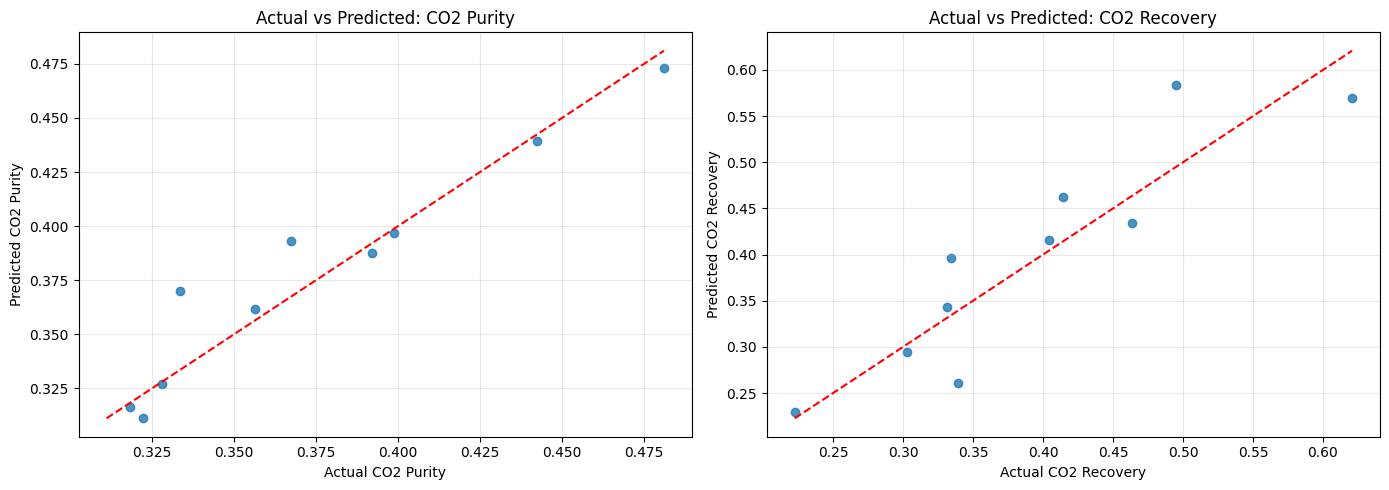

In [10]:
# 실제값과 예측값을 산점도로 비교합니다.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

purity_min = min(y_test_purity.min(), y_pred_purity.min())
purity_max = max(y_test_purity.max(), y_pred_purity.max())
recovery_min = min(y_test_recovery.min(), y_pred_recovery.min())
recovery_max = max(y_test_recovery.max(), y_pred_recovery.max())

axes[0].scatter(y_test_purity, y_pred_purity, alpha=0.8)
axes[0].plot([purity_min, purity_max], [purity_min, purity_max], 'r--')
axes[0].set_title('Actual vs Predicted: CO2 Purity')
axes[0].set_xlabel('Actual CO2 Purity')
axes[0].set_ylabel('Predicted CO2 Purity')
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test_recovery, y_pred_recovery, alpha=0.8)
axes[1].plot([recovery_min, recovery_max], [recovery_min, recovery_max], 'r--')
axes[1].set_title('Actual vs Predicted: CO2 Recovery')
axes[1].set_xlabel('Actual CO2 Recovery')
axes[1].set_ylabel('Predicted CO2 Recovery')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


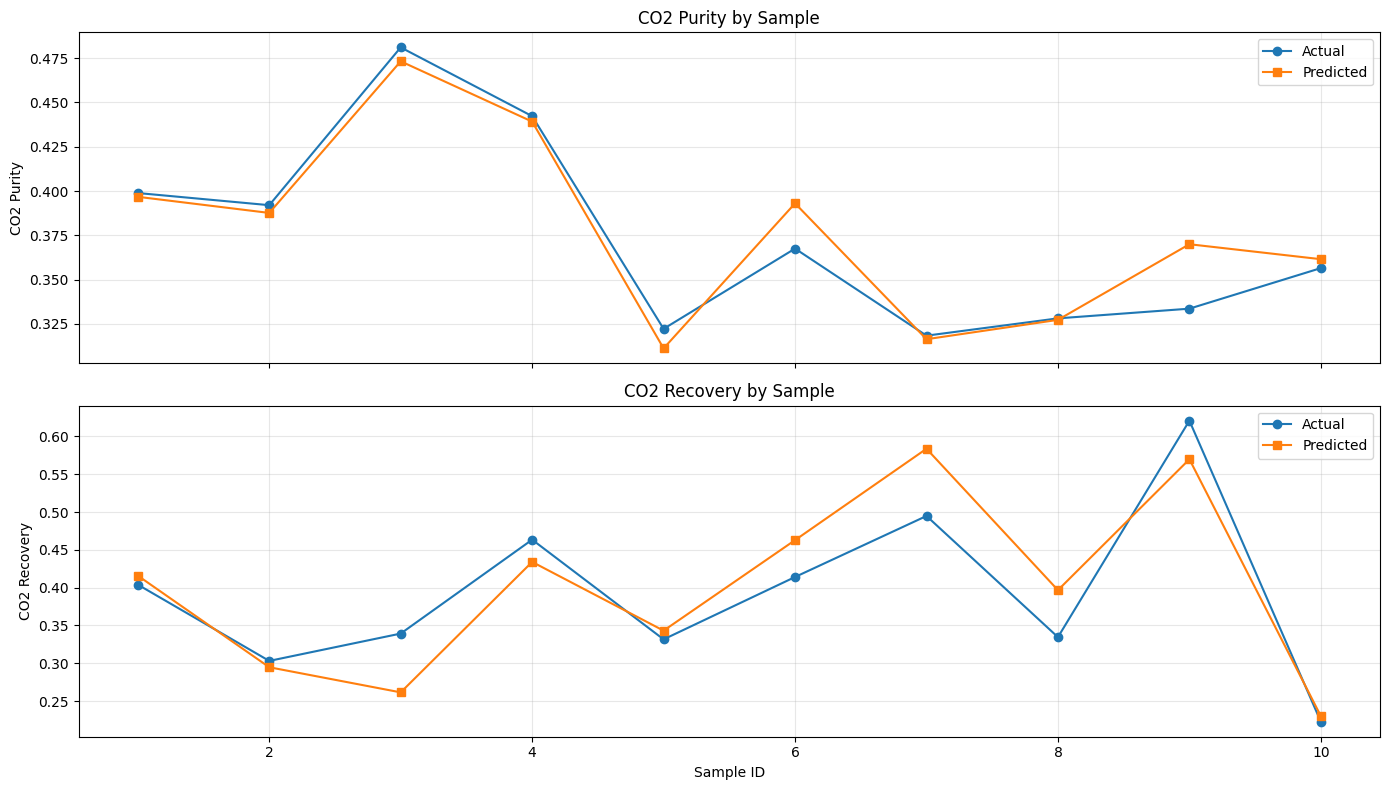

In [11]:
# 샘플별 실제값과 예측값을 선그래프로 비교합니다.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sample_axis = results_df['sample_id'] if 'sample_id' in results_df.columns else np.arange(len(results_df))

axes[0].plot(sample_axis, y_test_purity.values, marker='o', label='Actual')
axes[0].plot(sample_axis, y_pred_purity, marker='s', label='Predicted')
axes[0].set_title('CO2 Purity by Sample')
axes[0].set_ylabel('CO2 Purity')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(sample_axis, y_test_recovery.values, marker='o', label='Actual')
axes[1].plot(sample_axis, y_pred_recovery, marker='s', label='Predicted')
axes[1].set_title('CO2 Recovery by Sample')
axes[1].set_xlabel('Sample ID')
axes[1].set_ylabel('CO2 Recovery')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


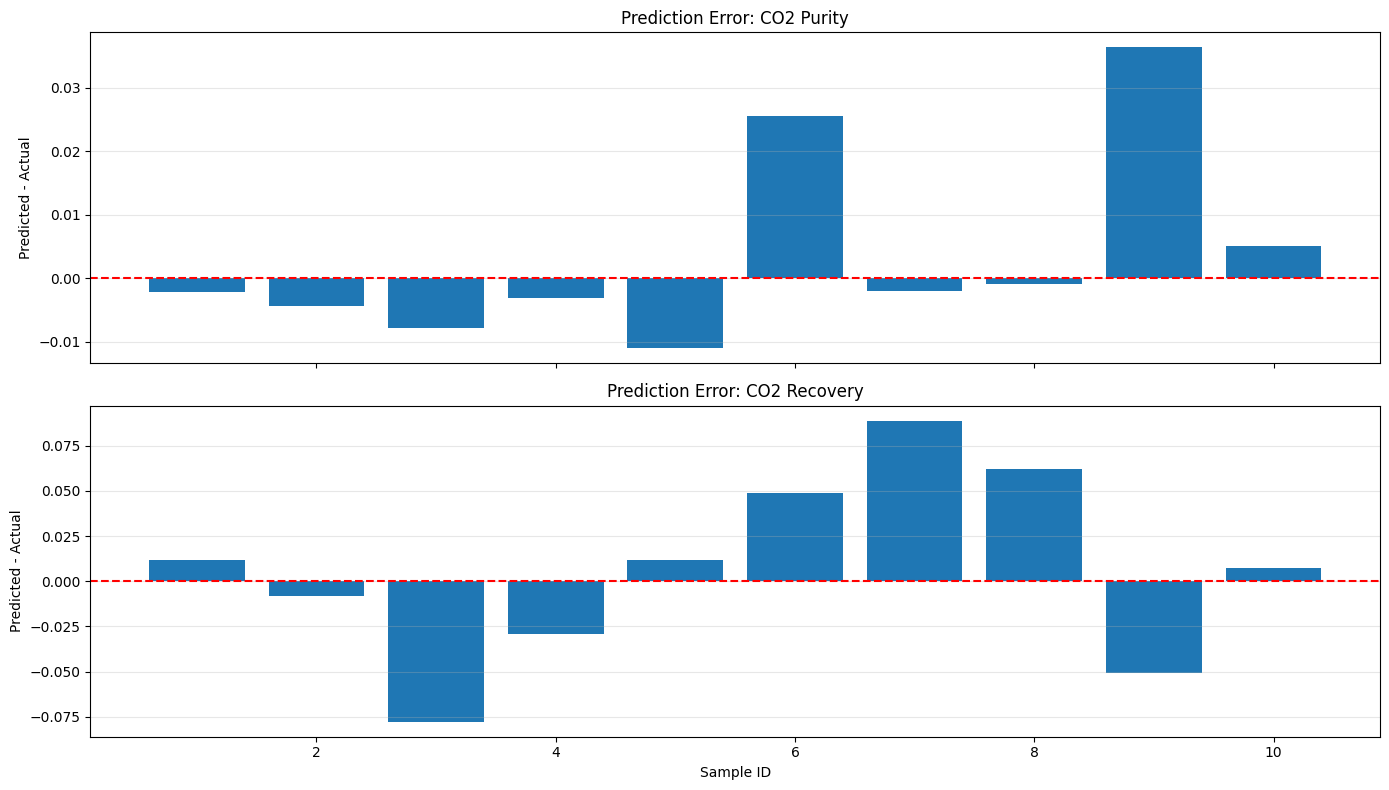

In [12]:
# 예측 오차를 막대그래프로 확인합니다.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sample_axis = results_df['sample_id'] if 'sample_id' in results_df.columns else np.arange(len(results_df))

axes[0].bar(sample_axis, results_df['purity_error'])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Prediction Error: CO2 Purity')
axes[0].set_ylabel('Predicted - Actual')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(sample_axis, results_df['recovery_error'])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Prediction Error: CO2 Recovery')
axes[1].set_xlabel('Sample ID')
axes[1].set_ylabel('Predicted - Actual')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
